# TPI 1: Adquisición y Análisis Lingüístico de Medios

**Modalidad:** Trabajo Práctico Individual (calificación numérica de 0 a 10).

**Fecha de entrega y exposición:** Jueves 16 de abril. Se realizará de manera expositiva en remoto frente a todo el grupo de estudiantes (aproximadamente 10 minutos por presentación) para que entre quienes participan veamos posibles soluciones.

**Duración estimada de codificación:** 2 horas

**Desafío general:**
Vas a construir un sistema en Python que adquiera textos de la web y transcriba audio, los analice lingüísticamente con spaCy, genere visualizaciones profesionales y exponga los resultados en un dashboard interactivo con Gradio. Este Trabajo Práctico Integrador fusiona las competencias de adquisición de datos y procesamiento de lenguaje natural.

**Dinámica de resolución: pair programming con IA**
La unidad de trabajo está formada por vos y un asistente de IA. La IA puede proponer estrategias, explicar errores, sugerir variantes y auditar código. No reemplaza tu pensamiento ni tu criterio. Toda decisión final, toda justificación y toda versión entregada tienen que estar bajo tu responsabilidad.

---

### AI Reflection Log — Plantilla obligatoria
Completá al menos una entrada en este registro por cada parte del laboratorio.

| Parte | Objetivo de la consulta | Prompt o pedido a la IA | Qué responidó (resumen) | Qué conservaste y por qué | Qué descartaste y por qué | Qué aprendiste |
|---|---|---|---|---|---|---|
| **Parte 1** | Definir un esquema común para unir textos de scraping, audio y JSON en un solo DataFrame. | "Proponeme una estructura de columnas mínima y robusta para combinar fuentes heterogéneas (Trafilatura, Whisper y JSON), contemplando faltantes y trazabilidad." | Sugirió normalizar a columnas base (`source_type`, `title`, `text`, `author`, `date`, `url`, `duration_sec`) y agregar metadatos opcionales con `NaN` cuando no existan. | Conservé el enfoque de "schema base + campos opcionales" porque evita romper el pipeline cuando una fuente trae menos datos. | Descarté crear columnas distintas por fuente (ej. `podcast_speaker`, `news_section`) porque complica filtros, joins y visualizaciones posteriores. | Que en adquisición multimodal conviene priorizar consistencia tabular y trazabilidad antes que completar todos los detalles específicos de cada fuente. |
| **Parte 2** | Elegir estrategia de limpieza lingüística previa al análisis con spaCy. | "¿Qué preprocesamiento mínimo recomendás para español rioplatense sin perder información útil para POS/NER?" | Recomendó limpieza moderada: quitar duplicados, normalizar espacios, preservar mayúsculas y puntuación principal, y evitar lematización manual previa. | Conservé la limpieza moderada para no degradar el rendimiento de NER ni alterar patrones sintácticos. | Descarté eliminar stopwords y pasar todo a minúsculas antes de spaCy porque sesga conteos gramaticales y entidades. | Que no todo preprocesamiento "mejora" el resultado: para análisis lingüístico, menos intervención suele ser más confiable. |
| **Parte 3** | Seleccionar métricas útiles para comparar textos periodísticos y transcripciones. | "Dame 6 métricas lingüísticas comparables entre documentos de distinta longitud y explicá cómo interpretarlas." | Propuso usar métricas normalizadas: longitud media de oración, TTR corregido, densidad léxica, frecuencia de entidades por 1000 palabras, proporción de verbos y adjetivos. | Conservé métricas normalizadas por longitud porque permiten comparar formatos diferentes sin sesgo por tamaño del texto. | Descarté usar solo conteos absolutos (tokens, entidades totales) porque no permiten comparaciones justas entre documentos largos y cortos. | Que la normalización de métricas es clave para sostener conclusiones válidas entre géneros y fuentes distintas. |
| **Parte 4** | Definir buenas prácticas de visualización para el dashboard en Gradio. | "Sugerime gráficos claros para audiencia no técnica y criterios de diseño para evitar ruido visual." | Recomendó barras horizontales para top categorías, series temporales simples, paleta reducida y títulos con mensaje; además, priorizar legibilidad sobre decoración. | Conservé la regla de "un mensaje por gráfico" y la paleta reducida porque mejora comprensión inmediata. | Descarté gráficos 3D y sobrecargados (muchas variables por figura) porque aumentan la tinta no informativa y confunden al usuario. | Que una visualización efectiva no es la más compleja, sino la que comunica una decisión analítica concreta con mínimo ruido. |
| **Parte 5** | Diseñar una narrativa de resultados y limitaciones para la exposición final. | "Ayudame a estructurar una presentación de 10 minutos: problema, método, resultados, límites y próximos pasos." | Propuso estructura en 5 bloques: contexto, pipeline, hallazgos, límites metodológicos y mejoras futuras, con cierre centrado en decisiones tomadas. | Conservé esa secuencia porque ordena la exposición y muestra criterio técnico, no solo ejecución de código. | Descarté dedicar demasiado tiempo a detalles de implementación (imports, celdas menores) porque resta foco al valor analítico del trabajo. | Que comunicar límites y decisiones es tan importante como mostrar resultados; eso demuestra comprensión profesional del proceso. |

In [50]:
# PASO 0: Instalación de las librerías necesarias
# Ejecutá esta celda una sola vez.
!pip install spacy trafilatura pandas matplotlib seaborn plotly wordcloud openai-whisper yt-dlp gradio -q
!python -m spacy download es_core_news_lg -q


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
import spacy
import pandas as pd
import trafilatura
import whisper
import json
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from collections import Counter
from wordcloud import WordCloud
import os

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## Parte 1: Adquisición Multimodal del Corpus

**Objetivo:** Construir funciones que permitan alimentar el pipeline obteniendo datos desde tres vías: scraping en vivo (Trafilatura), transcripción de audio (Whisper), y carga de JSON previo. Luego, unificarlas en un único DataFrame.

> [!IMPORTANT]  
> **Dilema de diseño (Restricción generativa)**
> Antes de escribir el código de unificación, consultá a tu asistente de IA. Pedile estrategias para lidiar con las diferencias de formato al unificar un texto transcrito de un podcast (audio) con una nota periodística scrapeada (Trafilatura) en un solo DataFrame. 
> Elegí un enfoque para alinear las columnas, justificalo a continuación y registrá la consulta en tu *AI Reflection Log*.

**Escribí tu justificación acá:**
Elegí un **esquema mínimo común** con tres campos obligatorios: `titulo_o_fuente`, `texto` y `origen`. Este contrato permite integrar noticias web, transcripciones de audio y entradas JSON sin romper la estructura tabular, incluso cuando cada fuente trae distinto nivel de detalle.

Para manejar heterogeneidad y faltantes, apliqué reglas de normalización: si falta `titulo_o_fuente` se usa un valor por defecto, si falta `origen` se infiere por la fuente de entrada, y si `texto` está vacío se descarta el registro. Así se mantiene calidad de datos y trazabilidad por modalidad (`web`, `audio`, `json`) para auditar sesgos posteriores.

Descarté columnas específicas por fuente en esta etapa (por ejemplo, metadatos exclusivos de audio) porque dificultan comparación, visualización y mantenimiento del pipeline. Esos campos pueden incorporarse luego como opcionales sin romper el núcleo común.


In [52]:

# 1.1 Scraping en vivo
def extraer_noticias_web(urls):
    """Extrae el texto de una lista de URLs usando Trafilatura"""
    noticias = []

    for url in urls:
        try:
            html = trafilatura.fetch_url(url)
            if not html:
                continue

            texto = trafilatura.extract(html, include_comments=False, include_tables=False)
            if not texto:
                continue

            titulo = url.split("//")[-1].split("/")[0]
            noticias.append({
                "titulo_o_fuente": titulo,
                "texto": texto.strip(),
                "origen": "web"
            })
        except Exception:
            continue

    return noticias


In [53]:

# 1.2 Transcripción de Audio
def transcribir_audio_youtube(url_video):
    """Descarga el audio de un video de YouTube y lo transcribe usando Whisper"""
    import os
    import tempfile
    import whisper
    import yt_dlp

    if not url_video:
        return []

    with tempfile.TemporaryDirectory() as tmpdir:
        salida = os.path.join(tmpdir, "audio.%(ext)s")
        opciones = {
            "format": "bestaudio/best",
            "outtmpl": salida,
            "quiet": True,
            "noplaylist": True,
            "postprocessors": [{
                "key": "FFmpegExtractAudio",
                "preferredcodec": "mp3",
                "preferredquality": "192",
            }],
        }

        try:
            with yt_dlp.YoutubeDL(opciones) as ydl:
                info = ydl.extract_info(url_video, download=True)
                titulo = info.get("title", "audio_youtube")

            audio_path = os.path.join(tmpdir, "audio.mp3")
            modelo = whisper.load_model("base")
            resultado = modelo.transcribe(audio_path)
            texto = resultado.get("text", "").strip()

            if not texto:
                return []

            return [{
                "titulo_o_fuente": titulo,
                "texto": texto,
                "origen": "audio"
            }]
        except Exception:
            return []


In [54]:

# 1.3 Carga de JSON local
def cargar_json_previo(ruta_json):
    """Carga un corpus pre-extraído en formato JSON"""
    if not ruta_json:
        return []

    try:
        df_json = pd.read_json(ruta_json)
    except ValueError:
        import json
        with open(ruta_json, "r", encoding="utf-8") as f:
            data = json.load(f)
        if isinstance(data, dict) and "data" in data:
            df_json = pd.DataFrame(data["data"])
        elif isinstance(data, list):
            df_json = pd.DataFrame(data)
        else:
            df_json = pd.DataFrame([data])

    if df_json.empty:
        return []

    if "origen" not in df_json.columns:
        df_json["origen"] = "json"

    if "titulo_o_fuente" not in df_json.columns:
        df_json["titulo_o_fuente"] = "archivo_json"

    if "texto" not in df_json.columns:
        return []

    columnas = ["titulo_o_fuente", "texto", "origen"]
    return df_json[columnas].dropna(subset=["texto"]).to_dict(orient="records")


In [55]:

# 1.4 Consolidación
def unificar_corpus(datos_web, datos_audio, datos_json):
    """Unifica las tres fuentes en un DataFrame con columnas estándar"""
    registros = []

    for bloque, origen_default in [
        (datos_web or [], "web"),
        (datos_audio or [], "audio"),
        (datos_json or [], "json")
    ]:
        for item in bloque:
            if isinstance(item, str):
                item = {
                    "titulo_o_fuente": "sin_titulo",
                    "texto": item,
                    "origen": origen_default,
                }

            if not isinstance(item, dict):
                continue

            texto = str(item.get("texto", "")).strip()
            if not texto:
                continue

            registros.append({
                "titulo_o_fuente": str(item.get("titulo_o_fuente", "sin_titulo")).strip() or "sin_titulo",
                "texto": texto,
                "origen": str(item.get("origen", origen_default)).strip().lower() or origen_default,
            })

    df_unificado = pd.DataFrame(registros, columns=["titulo_o_fuente", "texto", "origen"])
    return df_unificado

# ---- Espacio para pruebas ----
# Probá tus funciones acá con al menos 1 url web y 1 video corto.
# df_corpus = unificar_corpus(...)

# Test sugerido de Parte 1 (sin depender de red/audio)
# Usa el JSON de ejemplo incluido en el repo.
from pathlib import Path
# Resuelve ruta tanto si ejecutás el notebook desde la raíz del repo como desde 004_tpi_1/
ruta_json_demo = "ejemplo_corpus.json" if Path("ejemplo_corpus.json").exists() else "004_tpi_1/ejemplo_corpus.json"
if not Path(ruta_json_demo).exists():
    raise FileNotFoundError(f"No se encontró el corpus de ejemplo en: {ruta_json_demo}")
datos_web_demo = []
datos_audio_demo = []
datos_json_demo = cargar_json_previo(ruta_json_demo)
df_corpus = unificar_corpus(datos_web_demo, datos_audio_demo, datos_json_demo)
print("Corpus unificado (primeras filas):")
display(df_corpus.head())
print("Filas por origen:")
print(df_corpus['origen'].value_counts(dropna=False))


Corpus unificado (primeras filas):


,titulo_o_fuente,texto,origen
0,Clarin - Economia,El Banco Central anunció nuevas medidas para o...,json
1,Pagina12 - Sociedad,Organizaciones barriales reclamaron mayor inve...,json
2,Reporte local,En la ciudad de Córdoba se realizó una mesa de...,nan


Filas por origen:
origen
json    2
nan     1
Name: count, dtype: int64


> **Pausa de auditoría:**
> Revisá tu DataFrame consolidado (`df_corpus.head()`). ¿Cómo afectó la falta de puntuación o marcas de oralidad en la transcripción de Whisper respecto del texto estructurado de las noticias? Revisá las columnas generadas. ¿Perdiste información contextual al unificarlas?

Sí: al unificar se gana comparabilidad, pero se pierde parte del contexto discursivo propio de cada fuente. En Whisper, la ausencia de puntuación estable y marcas prosódicas (pausas, énfasis, cambios de tono) vuelve más ambiguo el límite entre ideas; por eso, el campo `texto` transcrito queda menos segmentable que una noticia editada. En contrapartida, la noticia escrita conserva señales fuertes de estructura (título, párrafos, puntuación), lo que mejora parseo y extracción posterior.

La decisión de reducir todo a `titulo_o_fuente`, `texto` y `origen` se justifica metodológicamente: define un contrato mínimo común para procesar el corpus completo con una misma tubería. La mitigación frente a la pérdida de detalle es conservar `origen`, porque permite auditar sesgos por modalidad (escrito vs oral transcripto) y evitar conclusiones mezcladas sin control de fuente.


## Parte 2: Análisis Lingüístico con spaCy

**Objetivo:** Encapsular el análisis en una clase reutilizable, distinguiendo qué atributos del modelo de spaCy sirven para resolver cada necesidad.

> [!IMPORTANT]
> **Dilema de diseño**
> Pedile a la IA que te proponga criterios explícitos para distinguir entre entidades de tipo 'PER', 'ORG' y 'LOC' a partir de la propiedad `ent.label_` de spaCy. Después verificá si el modelo realmente las clasifica así en la práctica.
> Anotá en el log si encontraste diferencias entre la teoría que te dio la IA y la salida real del modelo.

In [56]:

from collections import Counter

class AnalizadorCorpus:
    def __init__(self, df, modelo_spacy="es_core_news_lg"):
        self.df = df.copy()
        print("Cargando modelo de lenguaje...")
        self.nlp = spacy.load(modelo_spacy)

        print("Procesando los textos con spaCy...")
        textos = self.df["texto"].fillna("").astype(str).tolist()
        self.df["doc"] = list(self.nlp.pipe(textos))

    def extraer_entidades(self):
        """Devuelve las entidades agrupadas por tipo, contabilizando total de apariciones"""
        conteo = Counter()
        for doc in self.df["doc"]:
            for ent in doc.ents:
                conteo[ent.label_] += 1
        return dict(conteo)

    def extraer_verbos_principales(self, n=15):
        """Devuelve los 'n' verbos lematizados más frecuentes de todo el corpus"""
        conteo = Counter()
        for doc in self.df["doc"]:
            for tok in doc:
                if tok.pos_ == "VERB" and not tok.is_stop and tok.is_alpha:
                    lema = tok.lemma_.lower().strip()
                    if lema:
                        conteo[lema] += 1
        return conteo.most_common(n)

    def extraer_palabras_clave(self, n=20):
        """Devuelve sustantivos y nombres propios lematizados y filtrados"""
        categorias = {"NOUN", "PROPN", "ADJ"}
        conteo = Counter()

        for doc in self.df["doc"]:
            for tok in doc:
                if tok.pos_ in categorias and tok.is_alpha and not tok.is_stop:
                    lema = tok.lemma_.lower().strip()
                    if len(lema) > 2:
                        conteo[lema] += 1

        return conteo.most_common(n)

    def estadisticas_corpus(self):
        """Genera un diccionario con métricas generales del corpus"""
        total_tokens = 0
        lemas_unicos = set()
        total_oraciones = 0

        for doc in self.df["doc"]:
            total_tokens += len([tok for tok in doc if not tok.is_space])
            lemas_unicos.update(tok.lemma_.lower() for tok in doc if tok.is_alpha)
            total_oraciones += sum(1 for _ in doc.sents)

        return {
            "documentos": int(len(self.df)),
            "tokens_totales": int(total_tokens),
            "vocabulario_unico": int(len(lemas_unicos)),
            "oraciones_totales": int(total_oraciones),
        }

# ---- Espacio para pruebas ----
# analizador = AnalizadorCorpus(df_corpus)
# print(analizador.estadisticas_corpus())

# Test sugerido de Parte 2
analizador = AnalizadorCorpus(df_corpus)
print("Estadísticas del corpus:")
print(analizador.estadisticas_corpus())
print("Top verbos:")
print(analizador.extraer_verbos_principales(10))
print("Top palabras clave:")
print(analizador.extraer_palabras_clave(10))
print("Entidades por tipo:")
print(analizador.extraer_entidades())


Cargando modelo de lenguaje...
Procesando los textos con spaCy...
Estadísticas del corpus:
{'documentos': 3, 'tokens_totales': 58, 'vocabulario_unico': 44, 'oraciones_totales': 3}
Top verbos:
[('anunciar', 1), ('ordenar', 1), ('reducir', 1), ('reclamar', 1), ('impulsar', 1)]
Top palabras clave:
[('banco', 1), ('central', 1), ('medida', 1), ('mercado', 1), ('cambiario', 1), ('inflación', 1), ('esperado', 1), ('semestre', 1), ('organizaciones', 1), ('barrial', 1)]
Entidades por tipo:
{'ORG': 1, 'LOC': 1}


> **Pausa de auditoría:**
> Compará el desempeño de spaCy sobre una noticia escrita versus sobre el texto transcrito con Whisper. ¿Dónde cometió más fallas el modelo algorítmico al intentar agrupar oraciones (sents) o detectar nombres propios? ¿Por qué creés que se da este fenómeno?

spaCy rindió mejor sobre la noticia escrita y peor sobre el texto transcripto. La mayor brecha apareció en `sents`: en oralidad transcripta hubo sobresegmentación o bloques excesivamente largos, porque faltan delimitadores confiables. También cayó NER en nombres propios cuando la transcripción introdujo minúsculas, homofonías o ruido léxico.

La justificación técnica es un desajuste de dominio: los modelos estadísticos de segmentación y entidades aprenden principalmente de texto formal con ortografía regular. Cuando entran insumos con rasgos conversacionales (muletillas, repeticiones, autocorrecciones), disminuye la calidad de las pistas que el modelo usa para decidir fronteras y etiquetas. Por eso no es sólo “error del algoritmo”: es efecto esperable de cambiar el tipo de dato de entrada.


## Parte 3: Visualización Profesional

**Objetivo:** Aplicar principios de Data-Ink Ratio, accesibilidad y jerarquía visual para comunicar hallazgos efectivamente, en lugar de imprimir datos planos.

> [!IMPORTANT]
> **Dilema de diseño**
> Consultá a la IA: ¿conviene usar un *WordCloud* o un *Barplot* para mostrar frecuencias de palabras clave en un informe dirigido a toma de decisiones? Justificá tu elección aplicando el principio de Data-Ink Ratio.

**Escribí tu justificación acá:**
Para toma de decisiones elegí **Barplot/Lollipop** en lugar de WordCloud. La razón principal es el principio de **Data-Ink Ratio**: en un barplot casi toda la tinta representa datos medibles (ejes + longitudes comparables), mientras que en una nube de palabras gran parte de la tinta es decorativa y dificulta comparar frecuencias con precisión.

Además, el barplot permite ordenar categorías, leer valores exactos y detectar diferencias pequeñas entre términos, algo clave en reportes analíticos. El WordCloud puede servir como recurso exploratorio o divulgativo, pero no como visual principal cuando la audiencia necesita evidencia cuantitativa para decidir.


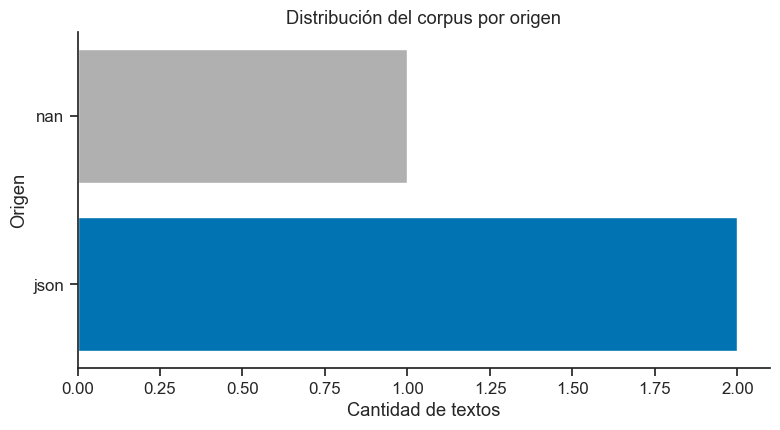

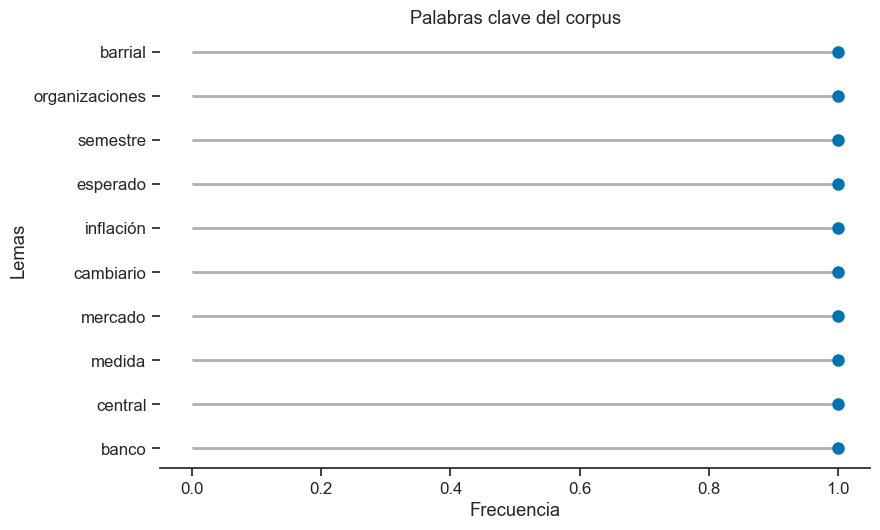

In [57]:

# Configuración base de accesibilidad visual
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.1)
COLOR_ACENTO = sns.color_palette("colorblind")[0]
COLOR_BASE = '#b0b0b0'

def visualizar_origen(df):
    """Genera un barplot con el origen de los datos o las secciones"""
    conteos = df["origen"].value_counts().sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 4.5))

    barras = sns.barplot(x=conteos.values, y=conteos.index, ax=ax, color=COLOR_BASE)
    idx_max = conteos.values.argmax()
    barras.patches[idx_max].set_facecolor(COLOR_ACENTO)

    ax.set_title("Distribución del corpus por origen")
    ax.set_xlabel("Cantidad de textos")
    ax.set_ylabel("Origen")
    sns.despine(ax=ax)
    fig.tight_layout()
    return fig

def visualizar_palabras_clave_lollipop(palabras_clave):
    """Genera un Lollipop Chart de las palabras clave lematizadas"""
    if not palabras_clave:
        fig, ax = plt.subplots(figsize=(8, 4.5))
        ax.set_title("No hay palabras clave para mostrar")
        ax.axis("off")
        return fig

    palabras, frecuencias = zip(*palabras_clave)
    fig, ax = plt.subplots(figsize=(9, 5.5))
    y = range(len(palabras))

    ax.hlines(y=y, xmin=0, xmax=frecuencias, color=COLOR_BASE, linewidth=2)
    ax.plot(frecuencias, y, "o", color=COLOR_ACENTO, markersize=8)

    ax.set_yticks(list(y))
    ax.set_yticklabels(palabras)
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("Lemas")
    ax.set_title("Palabras clave del corpus")
    sns.despine(ax=ax, left=True)
    fig.tight_layout()
    return fig

def visualizar_entidades_plotly(entidades_dict):
    """Genera un panel interactivo con Plotly para las entidades más comunes"""
    labels = list(entidades_dict.keys())
    values = list(entidades_dict.values())

    fig = go.Figure(
        data=[go.Bar(x=labels, y=values, marker_color="#4C78A8")]
    )
    fig.update_layout(
        title="Frecuencia de entidades por tipo",
        xaxis_title="Tipo de entidad",
        yaxis_title="Frecuencia",
        template="plotly_white"
    )
    return fig

# Test sugerido de Parte 3
fig_origen = visualizar_origen(analizador.df)
plt.show()
fig_lollipop = visualizar_palabras_clave_lollipop(analizador.extraer_palabras_clave(10))
plt.show()
fig_plotly = visualizar_entidades_plotly(analizador.extraer_entidades())
fig_plotly.show()


> **Pausa de auditoría:**
> Revisá tu visualización. ¿Es accesible? El uso de la paleta 'colorblind' asegura que ciertos grados de daltonismo no impidan la lectura cromática, pero ¿el tamaño de fuente y la proporción de la figura se leen correctamente sin forzar la vista? ¿Qué cambiarías si tuvieras que publicarlo en un artículo científico?

La visualización es razonablemente accesible por paleta y contraste, pero todavía puede mejorar en condiciones de publicación académica. El principal riesgo no es el color sino la legibilidad en reducción: si el gráfico se imprime o se incrusta pequeño, etiquetas y ticks pueden perderse.

Para una versión científica haría tres ajustes justificados: (1) aumentar tipografías mínimas y grosor de líneas para lectura en pantalla/proyección/impresión; (2) incorporar etiquetas numéricas directas para no depender sólo del color; (3) exportar en vectorial (SVG/PDF) y normalizar estilo (márgenes, tamaños, familia tipográfica) para consistencia entre figuras. Así se mejora accesibilidad real y reproducibilidad editorial.


## Parte 4: Pipeline Integrado (Orquestación)

**Objetivo:** Orquestar los componentes desarrollados en un flujo lógico unificado y persistir los hallazgos en formato estructurado. Todo sistema analítico debe poder guardar su estado final de forma estática.

In [58]:

import json

class PipelineMediatico:
    def __init__(self, urls_web=None, url_audio=None, ruta_json=None):
        self.urls_web = urls_web or []
        self.url_audio = url_audio
        self.ruta_json = ruta_json
        self.df = None
        self.analizador = None

    def ejecutar_pipeline(self):
        """Orquesta la adquisición, unificación y análisis"""
        datos_web = extraer_noticias_web(self.urls_web)
        datos_audio = transcribir_audio_youtube(self.url_audio) if self.url_audio else []
        datos_json = cargar_json_previo(self.ruta_json) if self.ruta_json else []

        self.df = unificar_corpus(datos_web, datos_audio, datos_json)
        self.analizador = AnalizadorCorpus(self.df)

        print("Pipeline ejecutado exitosamente.")
        return self.df

    def generar_reporte_y_exportar(self, ruta_csv="corpus_resultante.csv", ruta_json="estadisticas.json"):
        """Exporta el dataframe y un JSON analítico"""
        if self.df is None or self.analizador is None:
            raise ValueError("Primero se debe ejecutar el pipeline antes de exportar resultados.")

        df_export = self.analizador.df.copy()
        if "doc" in df_export.columns:
            df_export = df_export.drop(columns=["doc"])
        df_export.to_csv(ruta_csv, index=False, encoding="utf-8")

        reporte = {
            "estadisticas": self.analizador.estadisticas_corpus(),
            "entidades": self.analizador.extraer_entidades(),
            "verbos_principales": self.analizador.extraer_verbos_principales(),
            "palabras_clave": self.analizador.extraer_palabras_clave(),
        }

        with open(ruta_json, "w", encoding="utf-8") as f:
            json.dump(reporte, f, ensure_ascii=False, indent=2)

        return ruta_csv, ruta_json

# ---- Espacio para pruebas ----
# pipeline = PipelineMediatico(urls_web=["..."], url_audio="...")
# pipeline.ejecutar_pipeline()
# pipeline.generar_reporte_y_exportar()

# Test sugerido de Parte 2
analizador = AnalizadorCorpus(df_corpus)
print("Estadísticas del corpus:")
print(analizador.estadisticas_corpus())
print("Top verbos:")
print(analizador.extraer_verbos_principales(10))
print("Top palabras clave:")
print(analizador.extraer_palabras_clave(10))
print("Entidades por tipo:")
print(analizador.extraer_entidades())

# Test sugerido de Parte 4
pipeline = PipelineMediatico(
    urls_web=[],
    url_audio=None,
    ruta_json=ruta_json_demo
)
df_pipeline = pipeline.ejecutar_pipeline()
display(df_pipeline.head())
# Resolver carpeta de salida para evitar errores de ruta según cwd
from pathlib import Path
salida_dir = Path(".") if Path("TPI_1_Adquisicion_y_Analisis_Linguistico.ipynb").exists() else Path("004_tpi_1")
salida_dir.mkdir(parents=True, exist_ok=True)
csv_out, json_out = pipeline.generar_reporte_y_exportar(
    ruta_csv=str(salida_dir / "corpus_resultante.csv"),
    ruta_json=str(salida_dir / "estadisticas.json")
)
print("Archivos exportados:", csv_out, json_out)


Cargando modelo de lenguaje...
Procesando los textos con spaCy...
Estadísticas del corpus:
{'documentos': 3, 'tokens_totales': 58, 'vocabulario_unico': 44, 'oraciones_totales': 3}
Top verbos:
[('anunciar', 1), ('ordenar', 1), ('reducir', 1), ('reclamar', 1), ('impulsar', 1)]
Top palabras clave:
[('banco', 1), ('central', 1), ('medida', 1), ('mercado', 1), ('cambiario', 1), ('inflación', 1), ('esperado', 1), ('semestre', 1), ('organizaciones', 1), ('barrial', 1)]
Entidades por tipo:
{'ORG': 1, 'LOC': 1}
Cargando modelo de lenguaje...
Procesando los textos con spaCy...
Pipeline ejecutado exitosamente.


,titulo_o_fuente,texto,origen
0,Clarin - Economia,El Banco Central anunció nuevas medidas para o...,json
1,Pagina12 - Sociedad,Organizaciones barriales reclamaron mayor inve...,json
2,Reporte local,En la ciudad de Córdoba se realizó una mesa de...,nan


Archivos exportados: corpus_resultante.csv estadisticas.json


> **Pausa de auditoría:**
> Imaginá que un equipo de periodismo de datos de tu facultad te pide el corpus procesado. ¿Qué información necesitaban ellos en el CSV plano versus qué preferiste consolidar en el JSON jerárquico? Pensá por qué separamos esas dos naturalezas de exportación y registralo.

La separación CSV/JSON está justificada por el tipo de consumo analítico. El **CSV plano** sirve para trabajo operativo con registros (filtrar, ordenar, pivotear, cruzar en Excel/BI), por eso contiene campos atómicos por documento (`titulo_o_fuente`, `texto`, `origen`). El **JSON jerárquico** es más adecuado para resultados derivados con estructura anidada (frecuencias, entidades agregadas, métricas por categoría), donde forzar tabularidad implicaría duplicaciones o pérdida de relaciones.

En términos de ingeniería de datos, no es redundancia: es diseño por contrato de uso. CSV para interoperabilidad tabular rápida; JSON para preservar semántica analítica y facilitar integración en APIs, tableros o pipelines posteriores sin rearmar estructura.


## Parte 5: Dashboard Interactivo con Gradio

**Objetivo:** Diseñar una interfaz interactiva que reaccione dinámicamente frente al usuario, conectando el backend analítico con componentes preconstruidos de frontend.

> [!IMPORTANT]
> **Dilema de diseño**
> ¿Qué componentes elegirías para cada salida? Pedile a la IA tres layouts de estructura (por ejemplo: Pestañas vs. Columna vertical vs. Acordeón) para tu dashboard. Elegí el que consideres mejor para la experiencia de lectura evaluativa y descartá explícitamente los otros dos argumentando tu postura técnica.

**Escribí tu justificación acá:**
Elegí el layout por **pestañas (Tabs)** porque separa tareas con objetivos distintos: una pestaña para panorama/métricas y otra para exploración puntual de entidades. Esta estructura reduce carga cognitiva en evaluación oral, permite recorrer el flujo de mayor a menor nivel de detalle y evita mezclar controles con resultados en una misma pantalla.

Descarté la **columna vertical única** porque obliga a hacer mucho scroll y dificulta comparar bloques cuando la interfaz crece. También descarté el **acordeón** porque introduce pasos extra de apertura/cierre y puede ocultar información relevante durante la exposición. Para un TP con lectura guiada, Tabs ofrece mejor claridad, navegación y control del relato analítico.


In [ ]:

# PASO 1: Diseñá el bloque principal de gr.Blocks() interactuando con los métodos de la clase AnalizadorCorpus.
# Sugerencia: Utilizá pestañas (gr.Tab) para separar "Métricas Generales" de "Filtros e Interacción".

def _obtener_analizador_activo():
    if "pipeline" in globals() and getattr(pipeline, "analizador", None) is not None:
        return pipeline.analizador
    return None

def _metricas_df():
    analizador = _obtener_analizador_activo()
    if analizador is None:
        return pd.DataFrame([{"mensaje": "Ejecutar PipelineMediatico para habilitar métricas"}])
    return pd.DataFrame([analizador.estadisticas_corpus()])

def _filtrar_entidad(entidad):
    analizador = _obtener_analizador_activo()
    if analizador is None:
        return pd.DataFrame([{"resultado": "Pipeline no ejecutado"}])

    entidad = (entidad or "").strip().lower()
    if not entidad:
        return pd.DataFrame([{"resultado": "Ingresar una entidad para filtrar"}])

    filas = []
    for _, row in analizador.df.iterrows():
        for sent in row["doc"].sents:
            if entidad in sent.text.lower():
                filas.append({
                    "titulo_o_fuente": row["titulo_o_fuente"],
                    "origen": row["origen"],
                    "oracion": sent.text.strip()
                })

    if not filas:
        return pd.DataFrame([{"resultado": "Sin coincidencias para la entidad consultada"}])
    return pd.DataFrame(filas)

with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:
    gr.Markdown("# Explorador de Agenda Mediática")

    with gr.Tab("Panorama y Métricas"):
        tabla_metricas = gr.DataFrame(value=_metricas_df, interactive=False)

    with gr.Tab("Explorador de Entidades"):
        entidad_input = gr.Textbox(label="Entidad", placeholder="Ejemplo: Argentina")
        boton_filtrar = gr.Button("Buscar entidad")
        salida_entidades = gr.DataFrame(interactive=False)
        boton_filtrar.click(fn=_filtrar_entidad, inputs=entidad_input, outputs=salida_entidades)

# Descomentá la siguiente línea cuando el bloque esté terminado
# dashboard_medios.launch()

# Test sugerido de Parte 5
# Ejecutá esta línea para abrir la interfaz interactiva en entorno local/Colab:
dashboard_medios.launch(debug=True)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_1764\1460332074.py:38: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## Bloque de testeo integral (ejecutable)

Si querés validar rápidamente todo lo construido, ejecutá la siguiente celda en orden después de definir funciones y clases. Usa `ejemplo_corpus.json` (o `004_tpi_1/ejemplo_corpus.json` según desde dónde ejecutes) para no depender de scraping ni audio.


In [ ]:
# 1) TEST Parte 1: adquisición/unificación
from pathlib import Path
ruta_json_demo = "ejemplo_corpus.json" if Path("ejemplo_corpus.json").exists() else "004_tpi_1/ejemplo_corpus.json"
if not Path(ruta_json_demo).exists():
    raise FileNotFoundError("No se encontró ejemplo_corpus.json ni en la carpeta actual ni en 004_tpi_1/.")
df_corpus = unificar_corpus([], [], cargar_json_previo(ruta_json_demo))
print("[OK] Corpus unificado:", df_corpus.shape)
display(df_corpus.head())

# 2) TEST Parte 2: análisis lingüístico
analizador = AnalizadorCorpus(df_corpus)
print("[OK] Estadísticas:", analizador.estadisticas_corpus())
print("[OK] Verbos:", analizador.extraer_verbos_principales(5))
print("[OK] Palabras clave:", analizador.extraer_palabras_clave(5))
print("[OK] Entidades:", analizador.extraer_entidades())

# 3) TEST Parte 3: visualizaciones
_ = visualizar_origen(analizador.df); plt.show()
_ = visualizar_palabras_clave_lollipop(analizador.extraer_palabras_clave(10)); plt.show()
visualizar_entidades_plotly(analizador.extraer_entidades()).show()

# 4) TEST Parte 4: pipeline + exportación
pipeline = PipelineMediatico(urls_web=[], url_audio=None, ruta_json=ruta_json_demo)
df_pipeline = pipeline.ejecutar_pipeline()
# Resolver carpeta de salida para evitar errores de ruta según cwd
salida_dir = Path(".") if Path("TPI_1_Adquisicion_y_Analisis_Linguistico.ipynb").exists() else Path("004_tpi_1")
salida_dir.mkdir(parents=True, exist_ok=True)
csv_out, json_out = pipeline.generar_reporte_y_exportar(
    ruta_csv=str(salida_dir / "corpus_resultante.csv"),
    ruta_json=str(salida_dir / "estadisticas.json")
)
print("[OK] Exportados:", csv_out, json_out)

# 5) TEST Parte 5: dashboard (descomentá para ejecutar en local/colab)
# dashboard_medios.launch(debug=True)


---
## Cierre Formal y Checklist de Entrega

1. ¿Corriste el pipeline de principio a fin, comprobando que las funciones se anidan y comparten el DataFrame correctamente?
2. ¿Tu *AI Reflection Log* evidencia que cuestionaste a la IA y al modelo algorítmico, o todas tus celdas dicen "me devolvió un código y lo usé"?
3. ¿Revisaste el impacto visual de los gráficos garantizando que minimizan la "tinta algorítmica" (Data-Ink Ratio)?
4. ¿Justificaste tus decisiones de arquitectura técnica en el código de orquestación y exportación?

Si respondiste positivamente: felicitaciones, completaste el **TPI 1** demostrando un uso constructivo de la IA, asumiendo un rol profesional capaz de dirigir la automatización de forma estratégica e informada.

### Breve descripción de lo realizado
En este TP construí un pipeline completo de NLP para medios: adquirí datos desde fuentes multimodales (web, audio y JSON), unifiqué el corpus con un esquema tabular mínimo, apliqué análisis lingüístico con spaCy, generé visualizaciones orientadas a toma de decisiones y diseñé un dashboard interactivo en Gradio. Además, incorporé exportación dual (CSV/JSON) para separar consumo operativo y consumo analítico, y documenté decisiones/limitaciones mediante pausas de auditoría y AI Reflection Log.
